In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm

In [3]:
tickers=['AAPL','AMZN','TSLA','GOOGL','MSFT']
weights=np.array([0.20,0.20,0.20,0.20,0.20])
for t in tickers:
    data=yf.download(tickers,start="2022-1-1",end="2025-1-1",auto_adjust=False)['Adj Close']

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed


In [4]:
data.tail()

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2024-12-24,256.339752,229.050003,195.091003,434.179352,462.279999
2024-12-26,257.153839,227.050003,194.583649,432.973633,454.130005
2024-12-27,253.748535,223.750000,191.758408,425.482513,431.660004
2024-12-30,250.382965,221.300003,190.246307,419.849365,417.410004
2024-12-31,248.615799,219.389999,188.316376,416.558411,403.839996


In [5]:
returns=data.pct_change().dropna()
returns

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2022-01-04,-0.012692,-0.016916,-0.004083,-0.017147,-0.041833
2022-01-05,-0.026600,-0.018893,-0.045876,-0.038388,-0.053471
2022-01-06,-0.016693,-0.006711,-0.000200,-0.007902,-0.021523
2022-01-07,0.000989,-0.004288,-0.005303,0.000510,-0.035447
2022-01-10,0.000116,-0.006570,0.012061,0.000732,0.030342
...,...,...,...,...,...
2024-12-24,0.011478,0.017729,0.007604,0.009374,0.073572
2024-12-26,0.003176,-0.008732,-0.002601,-0.002777,-0.017630
2024-12-27,-0.013242,-0.014534,-0.014519,-0.017302,-0.049479


In [6]:
portfolio_returns=returns.dot(weights).dropna()
portfolio_returns

Date
2022-01-04   -0.018534
2022-01-05   -0.036646
2022-01-06   -0.010606
2022-01-07   -0.008708
2022-01-10    0.007336
                ...   
2024-12-24    0.023951
2024-12-26   -0.005713
2024-12-27   -0.021815
2024-12-30   -0.015670
2024-12-31   -0.013236
Length: 752, dtype: float64

In [7]:
#Baseline VAR

In [8]:
alpha = 0.99
VaR_99 = -np.percentile(portfolio_returns, 1)
print("Baseline 99% VaR:", round(VaR_99,4))


Baseline 99% VaR: 0.0466


In [9]:
# Stress Testing

In [10]:
#Scenario 1:AI Bubble Burst – Systemic Crash (-10%):2% for 5 days

In [22]:
stressed_ai_sys = returns.copy()
stressed_ai_sys.iloc[:5] -= 0.02

ai_systemic_crash = stressed_ai_sys.dot(weights)
ai_systemic_crash

Date
2022-01-04   -0.038534
2022-01-05   -0.056646
2022-01-06   -0.030606
2022-01-07   -0.028708
2022-01-10   -0.012664
                ...   
2024-12-24    0.023951
2024-12-26   -0.005713
2024-12-27   -0.021815
2024-12-30   -0.015670
2024-12-31   -0.013236
Length: 752, dtype: float64

In [23]:
#Scenario 2: AI Leaders Collapse (Tech Concentration Risk) -0.20% : 4% for 5 days

In [24]:
ai_names = ['AAPL','MSFT','GOOGL','AMZN','TSLA']

stressed_ai_conc = returns.copy()
stressed_ai_conc.loc[
    stressed_ai_conc.index[:5], ai_names
] -= 0.04

ai_concentration_crash = stressed_ai_conc.dot(weights)
ai_concentration_crash

Date
2022-01-04   -0.058534
2022-01-05   -0.076646
2022-01-06   -0.050606
2022-01-07   -0.048708
2022-01-10   -0.032664
                ...   
2024-12-24    0.023951
2024-12-26   -0.005713
2024-12-27   -0.021815
2024-12-30   -0.015670
2024-12-31   -0.013236
Length: 752, dtype: float64

In [25]:
# Scenario 3: Volatility Scaling (+60%)

In [26]:
vol_scaled_returns = returns * 1.6
vol_scaled_portfolio = vol_scaled_returns.dot(weights)
vol_scaled_portfolio

Date
2022-01-04   -0.029654
2022-01-05   -0.058633
2022-01-06   -0.016969
2022-01-07   -0.013933
2022-01-10    0.011738
                ...   
2024-12-24    0.038322
2024-12-26   -0.009140
2024-12-27   -0.034905
2024-12-30   -0.025072
2024-12-31   -0.021178
Length: 752, dtype: float64

In [27]:
# Scenario 4:Correlation Spike (ρ → 0.85)

In [28]:
corr = returns.corr()
corr_spike = corr * 0 + 0.85
np.fill_diagonal(corr_spike.values, 1)

std = returns.std()
cov_spike = np.outer(std, std) * corr_spike

L = np.linalg.cholesky(cov_spike)
z = np.random.normal(size=(len(returns), len(tickers)))
corr_spike_returns = z @ L.T
corr_spike_returns = pd.DataFrame(corr_spike_returns,
                                  index=returns.index,
                                  columns=tickers)

corr_spike_portfolio = corr_spike_returns.dot(weights)
corr_spike_portfolio

Date
2022-01-04    0.022421
2022-01-05    0.000972
2022-01-06    0.004831
2022-01-07   -0.020489
2022-01-10    0.020291
                ...   
2024-12-24   -0.040645
2024-12-26   -0.011998
2024-12-27   -0.018559
2024-12-30   -0.017886
2024-12-31    0.018478
Length: 752, dtype: float64

In [29]:
#Comparative Stressed VaR Table

In [33]:
scenarios = {
    "Baseline": portfolio_returns,
    "Systemic Crash (AI Bubble)":ai_systemic_crash,
    "AI Leaders Collapse":ai_concentration_crash,
    "Volatility Scaling (+60%)":vol_scaled_portfolio ,
    "Correlation Spike (ρ=0.85)":corr_spike_portfolio 
}

var_table = []

for name, r in scenarios.items():
    var_table.append([
        name,
        -np.percentile(r, 1),
        -np.percentile(r, 1) - VaR_99
    ])

var_df = pd.DataFrame(
    var_table,
    columns=["Scenario", "99% VaR", "Δ Capital vs Baseline"]
)

var_df


,Scenario,99% VaR,Δ Capital vs Baseline
0,Baseline,0.046619,0.000000
1,Systemic Crash (AI Bubble),0.048994,0.002376
2,AI Leaders Collapse,0.051665,0.005046
3,Volatility Scaling (+60%),0.074590,0.027971
4,Correlation Spike (ρ=0.85),0.055863,0.009245


In [34]:
# Plot

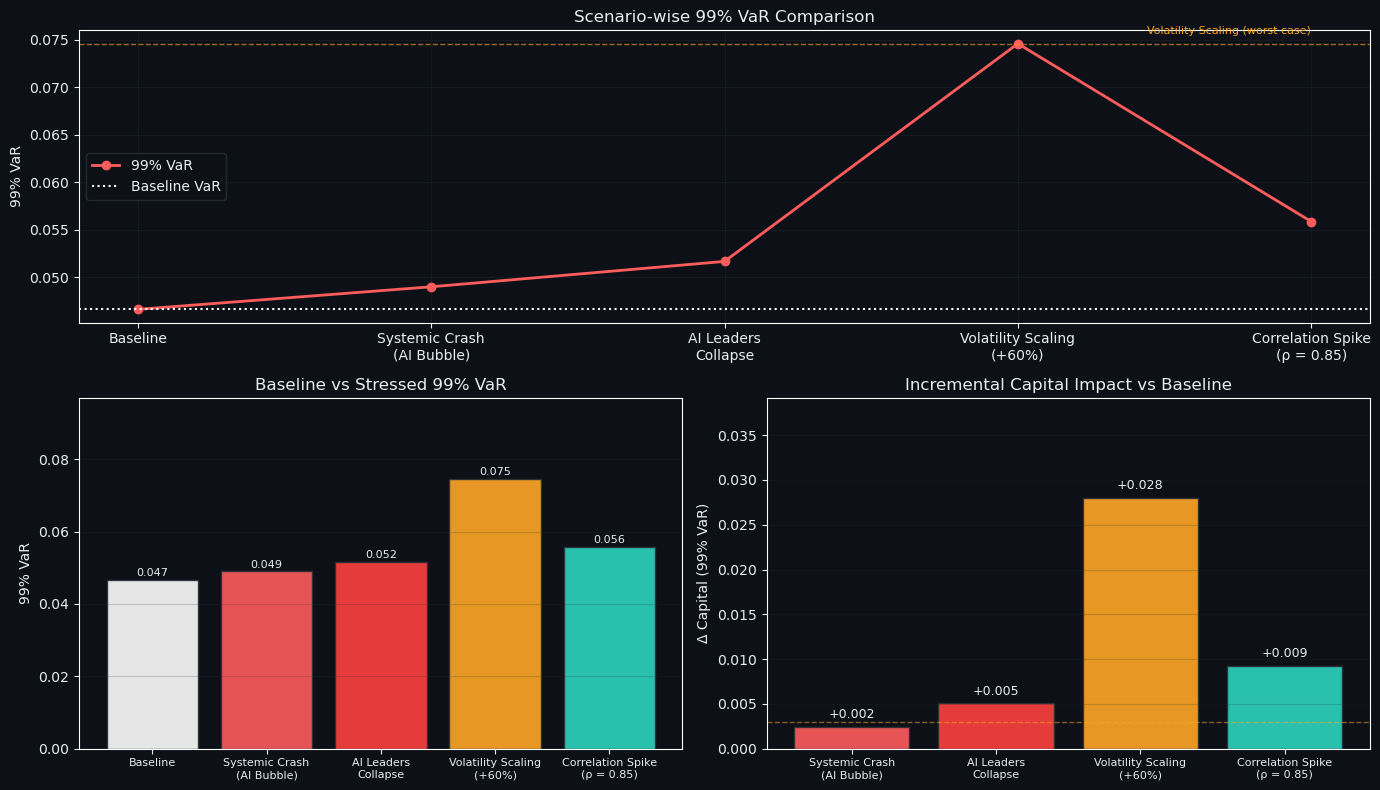

In [39]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

BG = "#0d1117"
GRID = "#2a2e37"
TEXT = "#e6edf3"

# Data (corrected)
scenarios = [
    "Baseline",
    "Systemic Crash\n(AI Bubble)",
    "AI Leaders\nCollapse",
    "Volatility Scaling\n(+60%)",
    "Correlation Spike\n(ρ = 0.85)"
]
var_99 = np.array([0.046619, 0.048994, 0.051665, 0.074590, 0.055863])
delta_cap = np.array([0.000000, 0.002376, 0.005046, 0.027971, 0.009245])

baseline_color = "#ffffff"      # white, matches base gilt yield line
stress_colors = ["#ff5c5c", "#ff4040", "#ffa726", "#2dd4bf"]
colors = [baseline_color] + stress_colors

# -------------------------------
fig = plt.figure(figsize=(14, 8), facecolor=BG)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

# Panel 1: Scenario Line Comparison
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor(BG)
ax1.plot(
    scenarios,
    var_99,
    marker='o',
    linewidth=2,
    color='#ff5c5c',
    label="99% VaR"
)
ax1.axhline(
    var_99[0], color='#ffffff', linestyle=':', linewidth=1.5, label="Baseline VaR"
)
ax1.axhline(
    var_99[3], color='#ffa726', linestyle='--', linewidth=1, alpha=0.6
)
ax1.text(len(scenarios)-1, var_99[3]+0.001, "Volatility Scaling (worst case)",
          color='#ffa726', fontsize=8, ha='right')
ax1.set_title("Scenario-wise 99% VaR Comparison", color=TEXT)
ax1.set_ylabel("99% VaR", color=TEXT)
ax1.legend(facecolor=BG, edgecolor=GRID, labelcolor=TEXT)
ax1.grid(alpha=0.3, color=GRID)
ax1.tick_params(colors=TEXT)

# Panel 2: Bar Chart - Baseline vs Stressed VaR
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor(BG)
bars = ax2.bar(scenarios, var_99, color=colors, alpha=0.9, edgecolor=GRID)
ax2.set_title("Baseline vs Stressed 99% VaR", color=TEXT)
ax2.set_ylabel("99% VaR", color=TEXT)
ax2.set_ylim(0, max(var_99) * 1.3)
ax2.tick_params(axis='x', labelsize=8, colors=TEXT)
ax2.tick_params(axis='y', colors=TEXT)
ax2.grid(alpha=0.2, color=GRID, axis='y')
for bar, v in zip(bars, var_99):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.001, f"{v:.3f}",
              ha='center', fontsize=8, color=TEXT)

# Panel 3: Incremental Capital Impact
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor(BG)
ax3.bar(
    scenarios[1:],
    delta_cap[1:],
    color=stress_colors,
    alpha=0.9,
    edgecolor=GRID
)
ax3.axhline(0.003, color='#ffa726', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_title("Incremental Capital Impact vs Baseline", color=TEXT)
ax3.set_ylabel("Δ Capital (99% VaR)", color=TEXT)
ax3.set_ylim(0, max(delta_cap) * 1.4)
ax3.tick_params(axis='x', labelsize=8, colors=TEXT)
ax3.tick_params(axis='y', colors=TEXT)
ax3.grid(alpha=0.2, color=GRID, axis='y')
for i, d in enumerate(delta_cap[1:]):
    ax3.text(i, d + 0.001, f"+{d:.3f}", ha='center', fontsize=9, color=TEXT)

plt.tight_layout()
plt.show()